# Retrieval Augmented Generation (RAG)

- LLM models are feeded with data and gives responses based on memorized data but it doesnot work with external files like csv, docs, etc. 
Now we need RAG. 
- RAG pulls information from csv and then generate answer based on retrived context.


- RAG is an advence framework of AI that combines infromation retrived through text generation model like GPTs and Geminies to produce more accurate
  and relivent up-to-date response.

## myth 

- RAG is dead
- Bigger the context window means you donot nedd RAG anymore.
- System (Millions of token):
  - cost is high
  - latency increase and system become slow
  - LLM performance is worst when it is overloaded

# R - Retrieve - Find usful information 
# A - Agument - Add it to AI knowledge 
# G - Generate - Create better response 


## Components of RAG : 

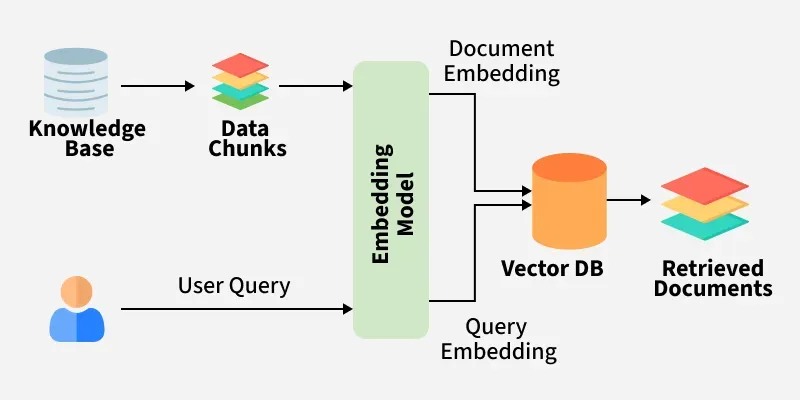




### 1. Ingestion: 

- Before retrieval documents must be processed stored in a system 
- This process requires breaking document into smaller pieces known as **chunks**
- A *native approach* is using fixed sized chunk. Fixed size chunks means splitting the document into equal token length(500 tokens per chunk)
- Main problem is:
  - Loss of context at chunk boundry
  - If a sentence is splitted between two chunks then it becomes incomplete.
- So we use **Semantic Chunking**:
  - Here embedding model can be used to analyze the text.
  - Frameworks like **longChain and Llama Index** they are built in to follow semantic chunking
- Hierarchical Chunking:
  - It allows retrival at different level of details(high level summary / detailed info)
  - It is commonly used with documents like **pdf, reports, or markdown files.**
    
### 2. Embedding Model: 
- After the documents is chunked each chunks is converted to an embedding.
- An embedding is a numerical vector that represent the *meaning of text.*
- When the user ask question the sytem convert it into the query is converted to embedding. This is known as semantic search.
- In 2026 embedding models like **text-embedding-3-large of OpenAI**, **voyage-3 Voyage AI**, **Open source: Hugging Fase: bge-large, E5-Mistral**

 ### 3. Vector Databases: 
 - sementic search result
 - Options: Qdrant, Milvus, ChromaDB, Waviate, pinecone
 - One factor is query latency at our expected scale.
 - Another is supporting meta-data filtering.


### RAG Design patterns you need to know: 

1) Simple RAG:
   - User ask a question -> You retrieve chunks -> You stuff them into a prompt --> LLM genertates you result
   - It is also known as Hello world in RAG
   - It is good for prototyping but not for production
     
3) RAG with Memory:
    - You add additional memory to the top of simple RAG 

   
5) Branched RAG:
    - Sometimes one query is not sufficient to answer the query so sometime RAG uses LLLM to decompose user query into subqueries where result is retrieved parallely and then they are sensized into a single coherent answer.
      
7) HyDE(Hypothetical Document Embedding):
    - It is cleaver and worth understanding query but  in simple RAG the problem is  Query embedded can generate multiple different result for same things. HyDE brige the gap by assing LLM to generate hypothetical answer before retrieving the result. Then more chances of getting good result.
      
9) Adoptive RAG
    - Not every question need RAG when asked for. e.g 2+2 =4 we donot need vecor database
    - 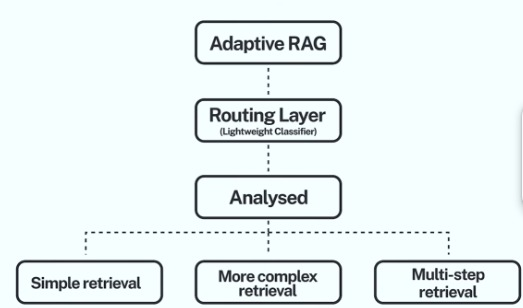

12) CRAG(Corrective RAG):
    - This address real failures mode like what happes when you retrieve document with low quality? or flat or irrelivence
    - 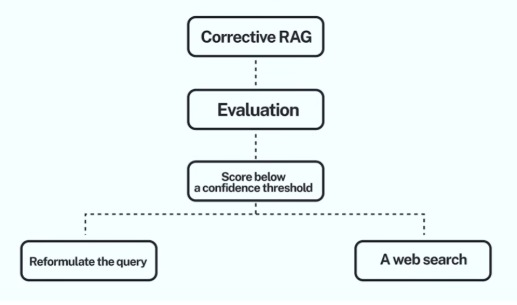

    
14) Self RAG:
    - It takes self correction idea further. The LLM is trained or prompt to generate reflection tokes while writing a answer.
16) Agentic RAG:
     - RAG needs an AI Agent. Agentic RAG uses an LLM model as an orchestrator that can decide what to do next.
     - Do it need to search for more info?
     - call API, retrieve info from differet source, decide it is enough.
     - Framework : LangGraph, Llamaindex
       
18) Multimodel RAG:

    - Most of the RAG system are designed for text. to handle chart, table, graph, images we use multimodel RAG
    - We use vision language models
      



## What Problems does RAG solve?
- Some the problems that RAG solves are:

- Hallucinations: Traditional generative models can produce incorrect information. RAG reduces this risk by retrieving verified, external data to ground responses in factual knowledge.
- Outdated Information: Static models rely on training data that may become outdated. It dynamically retrieves latest information ensuring relevance and accuracy in real time.
- Contextual Relevance: Generative models often struggle with maintaining context in complex or multi turn conversations. RAG retrieves relevant documents to enrich the context improving coherence and relevance.
- Domain Specific Knowledge: Generic models may lack expertise in specialized fields. It integrates domain specific external knowledge for tailored and precise responses.
- Cost and Efficiency: Fine tuning large models for specific tasks is expensive. It eliminates the need for retraining by dynamically retrieving relevant data reducing costs and computational load.
- Scalability Across Domains: It is adaptable to diverse industries from healthcare to finance without extensive retraining making it highly scalable.


## RAG Applications
Here are some examples to illustrate the applications of RAG we discussed earlier:

- Question-Answering Systems: It enables chatbots or virtual assistants to pull information from a knowledge base or documents and generate accurate,  context aware answers.
- Content Creation and Summarization: It can gather information from multiple sources and generate concise, simplified summaries or articles.
Conversational Agents and Chatbots: It enhances chatbots by grounding their responses in reliable data making interactions more informative and personalized.
- Information Retrieval: Goes beyond traditional search by retrieving documents and generating meaningful summaries of their content.
- Educational Tools and Resources: Provides students with explanations, diagrams or multimedia references tailored to their queries.

In [ ]:
### langchain -> RAG pipeline 
### langchain-community -> Ollama Integration 
### pydf -> For reading pdf 
### chromaDB -> Vector database 
### sentence-transformers -> Embedding  
### padas -> CSV file 



In [14]:
# ===============================================
# PDF Chatbot with LangChain + Ollama + FAISS
# Fully compatible with latest PyPI packages
# ===============================================

# 1️⃣ INSTALL REQUIRED PACKAGES (run once in CMD)
# pip install --upgrade pip
# pip install langchain[all] faiss-cpu ollama PyPDF2 pandas matplotlib

# 2️⃣ IMPORTS
from langchain.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.embeddings import OllamaEmbeddings
from langchain.llms import Ollama
from langchain.vectorstores import FAISS
from langchain.chains import RetrievalQA

# 3️⃣ LOAD PDF
pdf_file = "Backtracking.pdf"  # Replace with your PDF file
loader = PyPDFLoader(pdf_file)
docs = loader.load()
print(f"Loaded {len(docs)} pages from {pdf_file}")

# 4️⃣ SPLIT INTO CHUNKS
splitter = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=100)
chunks = splitter.split_documents(docs)
print(f"Total chunks created: {len(chunks)}")

# 5️⃣ CREATE EMBEDDINGS & VECTORSTORE
embeddings = OllamaEmbeddings(model="llama3:latest")  # Ollama embeddings
vector_store = FAISS.from_documents(chunks, embeddings)

# 6️⃣ CREATE RETRIEVER & RAG CHAIN
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k":3})
llm = Ollama(model="llama3:latest", temperature=0)
rag_qa = RetrievalQA.from_chain_type(llm=llm, chain_type="stuff", retriever=retriever)

# 7️⃣ OPTIONAL: KEY PHRASES TO HIGHLIGHT IN ANSWERS
key_phrases = ["Backtracking", "Algorithm", "Tree", "Graph"]  # Customize for your PDF

# 8️⃣ INTERACTIVE CHATBOT
print("\n=== PDF Chatbot ===")
print("Ask questions about your PDF. Type 'exit' to quit.\n")

while True:
    question = input("You: ")
    if question.lower() == "exit":
        break

    # Get answer from RAG
    answer = rag_qa.run(question)

    # Highlight key phrases
    highlighted_answer = answer
    for phrase in key_phrases:
        highlighted_answer = highlighted_answer.replace(phrase, f"**{phrase}**")

    print("\nChatbot:", highlighted_answer)
    print("="*50)

ModuleNotFoundError: No module named 'langchain.document_loaders'

In [2]:
from langchain.vectorstores import FAISS
from langchain.text_splitter import CharacterTextSplitter
from langchain_community.embeddings.ollama import OllamaEmbeddings
from langchain_community.llms.ollama import Ollama
from langchain.chains import RetrievalQA

ModuleNotFoundError: No module named 'langchain.vectorstores'

In [15]:
# ===============================================
# PDF Chatbot (LangChain + Ollama)
# Ask questions about your PDF interactively
# ===============================================

# 1️⃣ IMPORTS
import pandas as pd
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings.ollama import OllamaEmbeddings
from langchain_community.llms.ollama import Ollama
from langchain_community.vectorstores import FAISS
from langchain.chains import RetrievalQA

# 2️⃣ LOAD YOUR PDF
pdf_file = "Backtracking.pdf"  # replace with your PDF
loader = PyPDFLoader(pdf_file)
docs = loader.load()
print(f"Loaded {len(docs)} pages from {pdf_file}")

# 3️⃣ SPLIT INTO CHUNKS
splitter = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=100)
chunks = splitter.split_documents(docs)
print(f"Total chunks created: {len(chunks)}")

# 4️⃣ CREATE EMBEDDINGS (Ollama)
embeddings = OllamaEmbeddings(model="llama3:latest")

# 5️⃣ CREATE VECTOR STORE (FAISS)
vector_store = FAISS.from_documents(chunks, embeddings)

# 6️⃣ CREATE RAG RETRIEVER
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k":3})

# 7️⃣ CREATE LLM (Ollama)
llm = Ollama(model="llama3:latest", temperature=0)

# 8️⃣ CREATE RAG QA CHAIN
rag_qa = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=retriever
)

# 9️⃣ INTERACTIVE CHAT
print("\n=== PDF Chatbot ===")
print("Ask questions about your PDF. Type 'exit' to quit.\n")

key_phrases = ["Backtracking", "Algorithm", "Tree", "Graph"]  # Customize for your PDF

while True:
    question = input("You: ")
    if question.lower() == "exit":
        break

    # --- Get answer from RAG ---
    answer = rag_qa.run(question)

    # --- Highlight key phrases ---
    highlighted_answer = answer
    for phrase in key_phrases:
        highlighted_answer = highlighted_answer.replace(phrase, f"**{phrase}**")

    print("\nChatbot:", highlighted_answer)
    print("="*50)

ModuleNotFoundError: No module named 'langchain_community'